In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

In [17]:
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > 1e-6:
        raise RuntimeError(
            f"Self-consistency violated: max |Δ| = {max_err:e}"
        )

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
    if max_err > check_tol:
        mag = np.abs(eigvals)
        print("Sorted |eigvals|:", np.sort(mag))
        raise RuntimeError(
            fr"Self-consistency violated: max |Δ| = {max_err}"
        )

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    G_RL = G_DD_r[-d_device:, :d_device]
    return G_RL , Sigma_R, Sigma_L

def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导
    """
    G_total_at_E = 0.0  
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(
            H_q_list=mats["H_q_list"],
            H_l=mats["H_l"],
            H_r=mats["H_r"],
            T_21=mats["T_21"],
            T_LD=mats["T_LD"],
            T_l=mats["T_l"],
            T_RD=mats["T_RD"],
            T_r=mats["T_r"],
            xshumu=xshumu, 
            E=E_val,
            eta=eta
        )
        
        # 计算左右电极的展宽矩阵
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        # 计算当前模式的透射率并累加
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E
    

In [46]:
random_potentials = np.random.uniform(-W_disorder/2, W_disorder/2, xshumu)

In [ ]:
#中间矩阵信息  形纳米管ky量子化，周长2b*m
#sx = np.array([[0, 1], [1, 0]], complex)
#sy = np.array([[0, -1j], [1j, 0]], complex)
#sz = np.array([[1, 0], [0, -1]], complex)
#s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie(u):
    return u * np.array([[1]], dtype=complex)

def H_hop(t):
    return t*np.array([[1]], dtype=complex)

mu_q=0
mu_r=-0
mu_l=-0
t=-1
xshumu=10 
W_disorder = 1.0 


T_21 = H_hop(t)
H_q_list = []

for rand_val in random_potentials:
    H_q_random = H_onstie(mu_q + rand_val)
    H_q_list.append(H_q_random)


H_l = H_onstie(mu_l)
T_l = H_hop(t).conj().T

H_r = H_onstie(mu_r)
T_r = H_hop(t)

T_LD = H_hop(t)
T_RD = H_hop(t).conj().T
E_set=np.linspace(-3, 3, 200)
G_set=[]
for E in E_set:
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_set.append(G_complex)

k_vals = np.linspace(0, 2 * np.pi, 300)
E_k_matrix = H_q + T_21 * np.exp(1j * k_vals) + T_21.conj().T * np.exp(-1j * k_vals)
E_k = np.squeeze(E_k_matrix)


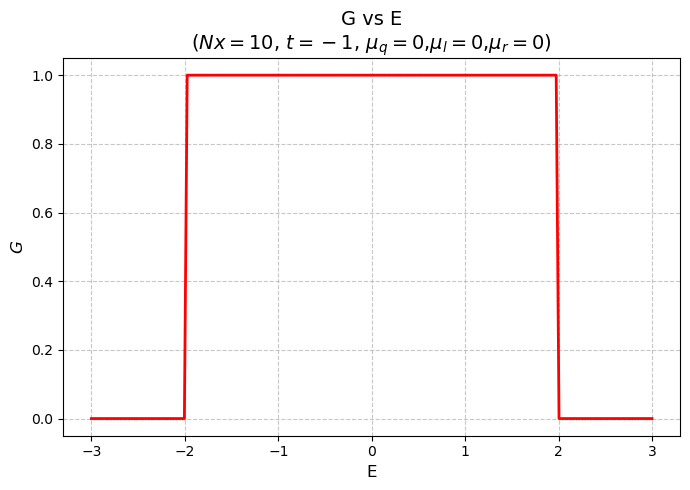

In [32]:
plt.figure(figsize=(7, 5))
plt.plot(E_set, G_set, marker='o', markersize=0.1, color='r', linewidth=2, linestyle='-')


plt.title(f'G vs E\n' + 
          rf'($Nx={xshumu}$, $t={t}$, $\mu_q={mu_q}$,$\mu_l={mu_l}$,$\mu_r={mu_r}$)', fontsize=14)
plt.xlabel(r'E', fontsize=12)
plt.ylabel(r'$G$', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()




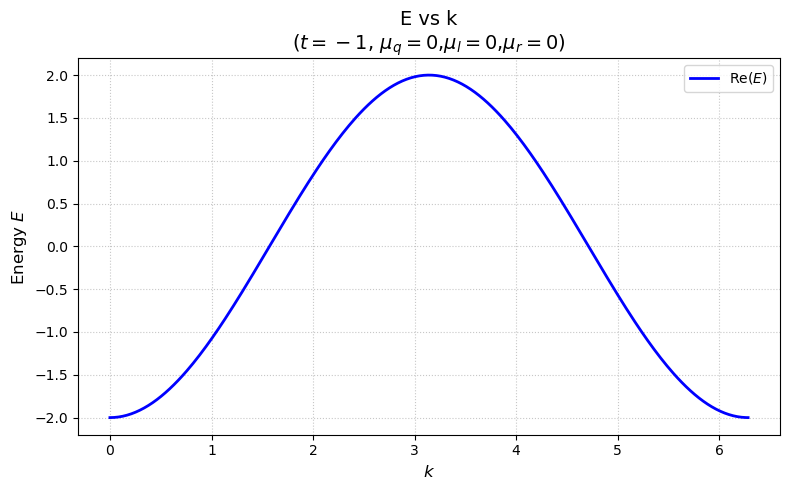

In [37]:
k_vals = np.linspace(0, 2 * np.pi, 300)
E_k = H_q + T_21 * np.exp(1j * k_vals) + T_21.conj().T * np.exp(-1j * k_vals)
E_k = np.squeeze(E_k)

plt.figure(figsize=(8, 5))

# 横轴为 k_vals，纵轴分别为 E_k 的实部和虚部
plt.plot(k_vals, np.real(E_k), color='blue', linewidth=2, label=r'$\operatorname{Re}(E)$')
#plt.plot(k_vals, np.imag(E_k), color='red', linewidth=2, linestyle='--', label=r'$\operatorname{Im}(E)$')

# 设置图表信息
plt.title(f'E vs k\n' + 
          rf'($t={t}$, $\mu_q={mu_q}$,$\mu_l={mu_l}$,$\mu_r={mu_r}$)', fontsize=14)
plt.xlabel(r'$k$', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

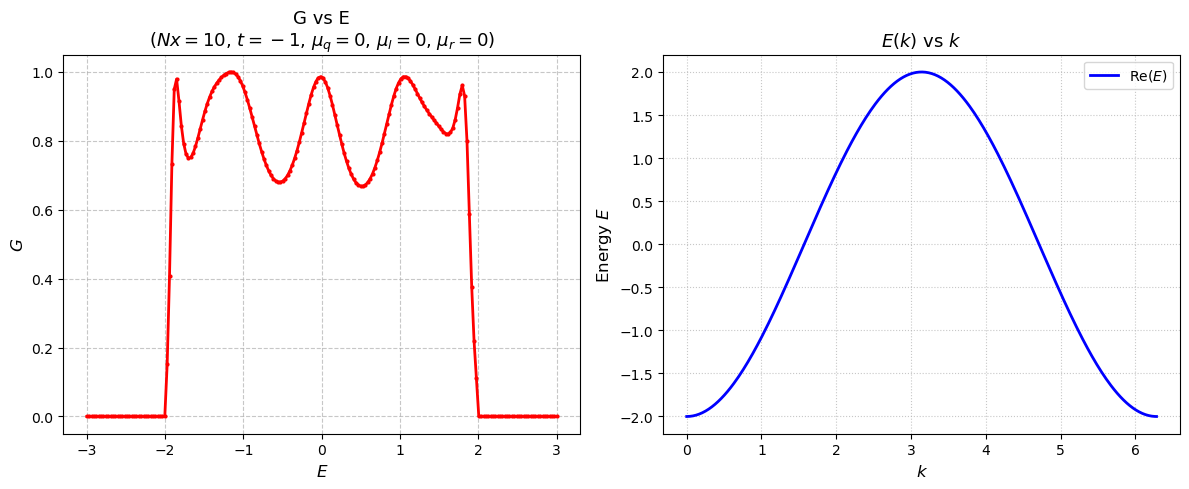

In [ ]:
# 创建 1行2列 的画布，尺寸可以稍微拉长一点
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ================= 1. 左图：G vs E =================
ax1.plot(E_set, G_set, marker='o', markersize=2, color='r', linewidth=2, linestyle='-')
ax1.set_title(f'G vs E\n' + 
              rf'($Nx={xshumu}$, $t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', fontsize=13)
ax1.set_xlabel(r'$E$', fontsize=12)
ax1.set_ylabel(r'$G$', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# ================= 2. 右图：E(k) vs k =================
ax2.plot(k_vals, np.real(E_k), color='blue', linewidth=2, label=r'$\operatorname{Re}(E)$')
#ax2.plot(k_vals, np.imag(E_k), color='red', linewidth=2, linestyle='--', label=r'$\operatorname{Im}(E)$')

# 设置图表信息
ax2.set_title(f'$E(k)$ vs $k$', fontsize=13)
ax2.set_xlabel(r'$k$', fontsize=12)
ax2.set_ylabel('Energy $E$', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

# 调整布局防止重叠，并显示
plt.tight_layout()
plt.show()